In [1]:
import sys, os
sys.path.insert(1, '../..')

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import networkx as nx
import pickle
from itertools import combinations
import config.config as conf
import json
from collections import Counter

In [3]:
net_result = f'{conf.DATA_PATH}{conf.NETWORK_RESULT}'
net_src = f'{conf.DATA_PATH}{conf.NETWORK_SRC}'


In [4]:
file_list = sorted(os.listdir(f'{net_src}'))

In [5]:
file_list

['qna_2122.csv',
 'qna_2124.csv',
 'qna_2223.csv',
 'qna_2324.csv',
 'reputation_dict.json']

In [6]:
df_qna_2122 = pd.read_csv(f'{net_src}/qna_2122.csv', index_col=False)

In [7]:
df_qna_2122

,Unnamed: 0,Source,Target
0,1525,3849766,1174102
1,1667,2034854,20362173
2,1829,22283075,3517025
3,1888,22251943,17728467
4,1893,22253761,19207606
...,...,...,...
250599,443102,901925,9074215
250600,443103,8372455,8372455
250601,443104,13418705,17640264
250602,443105,3799759,13837517


In [8]:
df_qna_2122[df_qna_2122['Source'] ==10693596]

,Unnamed: 0,Source,Target
903,4929,10693596,19129620
995,5021,10693596,18158583
2437,6463,10693596,688859
3088,7114,10693596,2875917
6907,16045,10693596,7437143
...,...,...,...
244110,432246,10693596,13873088
244186,432322,10693596,19293631
247553,437754,10693596,18027620
247723,437924,10693596,17782326


In [9]:
df_qna_2122 = df_qna_2122[df_qna_2122['Source'] != df_qna_2122['Target']]

In [10]:
with open(f'{net_src}/reputation_dict.json', 'r', encoding='utf-8') as f:
    reputation_dict = json.load(f)

In [11]:
reputation_dict['10693596']

10637

In [12]:
node_df = pd.DataFrame(zip(reputation_dict.keys(), reputation_dict.values()), columns=['node', 'weight'])

In [13]:
df_qna_2122 = df_qna_2122.astype('str')

In [14]:
def get_network(df) : 
    node = np.unique(np.append(df['Source'].values, df['Target'].values))
    edgelist = list(zip(df['Source'], df['Target']))
    edge_counter = Counter(edgelist)

    G = nx.DiGraph()
    G.add_nodes_from(node)
    for (u, v), cnt in edge_counter.items():
        G.add_edge(str(u), str(v), weight=int(cnt))

    degree = {k: int(v) for k, v in G.degree()}
    in_deg = {k: int(v) for k, v in G.in_degree()}
    out_deg = {k: int(v) for k, v in G.out_degree()}

    nx.set_node_attributes(G, degree, 'degree')
    # in-degree
    nx.set_node_attributes(G, in_deg, 'in_degree')
    # out-degree
    nx.set_node_attributes(G, out_deg, 'out_degree')

    nx.set_node_attributes(G, { keys: float(np.log(values+23))  for keys, values in reputation_dict.items()}, name='weight')

    return G

In [15]:
g_2122 = get_network(df_qna_2122)

In [16]:
reputation_log_dict = {key : np.log(x+23) for key, x in reputation_dict.items()}

(array([7.0000e+00, 1.1856e+04, 9.0848e+04, 2.3541e+04, 1.1346e+04,
        5.2790e+03, 1.9280e+03, 5.3800e+02, 7.6000e+01, 7.0000e+00]),
 array([ 0.        ,  1.54685515,  3.0937103 ,  4.64056545,  6.1874206 ,
         7.73427575,  9.28113089, 10.82798604, 12.37484119, 13.92169634,
        15.46855149]),
 <BarContainer object of 10 artists>)

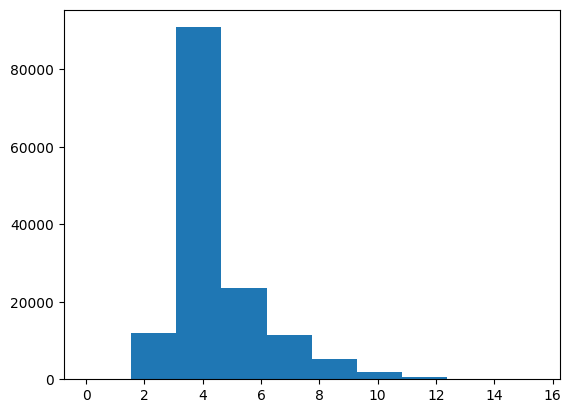

In [17]:
plt.hist(list([np.log(x+23) for x in reputation_dict.values()]))

In [18]:
max(nx.get_edge_attributes(g_2122, 'weight').values())

34

In [19]:
nx.get_node_attributes(g_2122, 'weight')

{'1000026': 6.695798917058491,
 '10000270': 3.1354942159291497,
 '10000305': 4.770684624465665,
 '10000640': 3.1354942159291497,
 '10000823': 7.4109518755836366,
 '10000830': 4.454347296253507,
 '10001055': 6.104793232414985,
 '10001217': 4.543294782270004,
 '10001537': 3.1354942159291497,
 '10001664': 5.030437921392435,
 '10001688': 8.504918160540624,
 '10001707': 4.418840607796598,
 '10002023': 3.7612001156935624,
 '10002140': 4.727387818712341,
 '10002202': 5.393627546352362,
 '10002278': 3.367295829986474,
 '10002483': 5.342334251964811,
 '10002847': 3.044522437723423,
 '10002907': 5.707110264748875,
 '10003008': 6.96979066990159,
 '10003279': 3.6109179126442243,
 '10003370': 3.713572066704308,
 '1000343': 11.61301511398424,
 '10003538': 6.762729506931879,
 '1000378': 8.567125560164447,
 '10004072': 6.637258031284457,
 '10004367': 3.1354942159291497,
 '10004540': 3.4965075614664802,
 '10004709': 4.574710978503383,
 '10004835': 4.795790545596741,
 '10004868': 3.8501476017100584,
 '1

In [20]:

def find_transitive_edges(G):
    G2 = G.copy()
    transitive_edges = []

    # ⭐️ edges를 list로 고정
    edges = list(G2.edges())

    for u, v in edges:
        # edge 임시 제거
        G2.remove_edge(u, v)

        # 다른 경로가 존재하면 transitive
        if nx.has_path(G2, u, v):
            transitive_edges.append((u, v))

        # edge 복구
        G2.add_edge(u, v)

    return transitive_edges

In [21]:
trans_edges = find_transitive_edges(g_2122)
trans_set = set(trans_edges)


In [27]:
max(nx.get_edge_attributes(g_2122, 'weight').values())

34

In [28]:
node_trans_out = {n: 0 for n in g_2122.nodes()}

for u, v in trans_set:
    if u in node_trans_out:
        node_trans_out[u] += 1

In [29]:
node_trans_in = {n: 0 for n in g_2122.nodes()}

for u, v in trans_set:
    if v in node_trans_in:
        node_trans_in[v] += 1


In [30]:
node_trans_total = {
    n: node_trans_in.get(n, 0) + node_trans_out.get(n, 0)
    for n in g_2122.nodes()
}


In [31]:
max(nx.get_edge_attributes(g_2122, 'weight').values())

34

In [32]:
df1 = pd.DataFrame(zip(node_trans_out.keys(), [np.log(x+0.01) for x in node_trans_out.values()]), columns=['id', 'tran'])
df2 = pd.DataFrame(zip(node_trans_in.keys(), node_trans_in.values()), columns=['id', 'tran'])
df3 = pd.DataFrame(zip(node_trans_total.keys(), node_trans_total.values()), columns=['id', 'tran'])

df_repu = pd.DataFrame(zip(reputation_dict.keys(), [np.log(x+23) for x in reputation_dict.values()]), columns=['id', 'repu'])


In [33]:
df_merge_1 =    pd.merge(df1 , df_repu, on = ['id'])
df_merge_2 =    pd.merge(df2 , df_repu, on = ['id'])
df_merge_3 =    pd.merge(df3 , df_repu, on = ['id'])

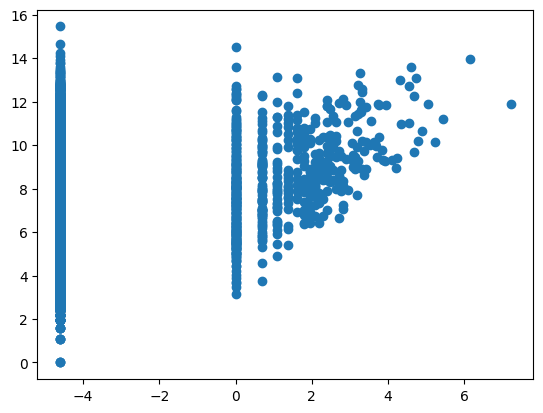

In [34]:
plt.scatter(df_merge_1['tran'], df_merge_1['repu'])

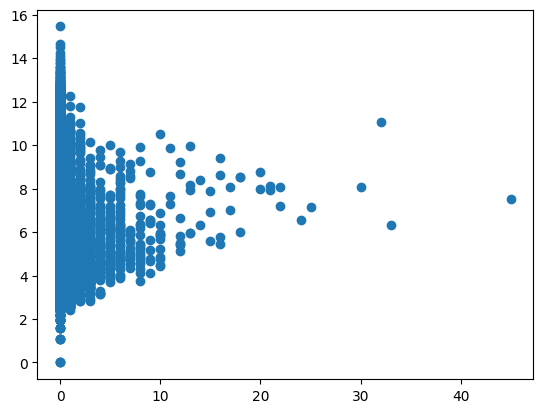

In [35]:
plt.scatter(df_merge_2['tran'], df_merge_2['repu'])

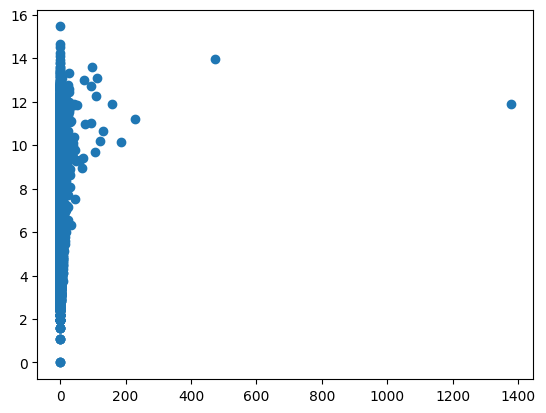

In [36]:
plt.scatter(df_merge_3['tran'], df_merge_3['repu'])

In [37]:
max(nx.get_edge_attributes(g_2122, 'weight').values())

34

In [38]:
ec = nx.eigenvector_centrality(
    g_2122,
    weight='weight'
)

In [39]:
ec

{'1000026': 2.547533850104388e-13,
 '10000270': 5.095067700208776e-12,
 '10000305': 5.095067700208776e-12,
 '10000640': 3.003542409273074e-10,
 '10000823': 9.935382015407106e-12,
 '10000830': 5.095067700208776e-12,
 '10001055': 2.4456324961002134e-11,
 '10001217': 2.547533850104388e-13,
 '10001537': 2.547533850104388e-13,
 '10001664': 2.547533850104388e-13,
 '10001688': 2.547533850104388e-13,
 '10001707': 2.547533850104388e-13,
 '10002023': 5.095067700208776e-12,
 '10002140': 5.465708400060463e-08,
 '10002202': 9.935382015407106e-12,
 '10002278': 9.935382015407106e-12,
 '10002483': 5.095067700208776e-12,
 '10002847': 1.4062386852576224e-10,
 '10002907': 5.095067700208776e-12,
 '10003008': 2.547533850104388e-13,
 '10003279': 5.095067700208776e-12,
 '10003370': 3.930360699279551e-08,
 '1000343': 1.5491553342484786e-09,
 '10003538': 1.3410218186949501e-09,
 '1000378': 2.547533850104388e-13,
 '10004072': 2.547533850104388e-13,
 '10004367': 9.935382015407106e-12,
 '10004540': 2.547533850104

In [40]:
values = np.array(list(ec.values()))
threshold = np.percentile(values, 90)
top_nodes = [n for n, v in ec.items() if v >= threshold]


In [41]:
len(top_nodes)
# 31973
# 145426

13931

In [42]:
G_top = g_2122.subgraph(top_nodes).copy()


In [43]:
deg = dict(G_top.degree())

In [44]:
selected_nodes = [n for n, d in deg.items() if d > 1]

In [45]:
G_deg = G_top.subgraph(selected_nodes).copy()

In [46]:
trans_set = set(find_transitive_edges(G_deg))

In [47]:
for u, v in G_deg.edges():
    if (u, v) in trans_set:
        G_deg[u][v]['transitive'] =1
    else:
        G_deg[u][v]['transitive'] = 0


In [48]:
print(len(G_deg.nodes()))
print(len(G_deg.edges()))

2342
4051


In [49]:
max(nx.get_edge_attributes(G_deg, 'weight').values())

10

In [50]:
nx.write_gexf(G_deg, "G_deg_transitivity.gexf")